# K Nearest Neighbours

K-Nearest Neighbors (KNN) is one of the most intuitive and widely used classification algorithms in machine learning. It is a non-parametric, instance-based learning method, which means it doesn't explicitly learn a model during the training phase. Instead, it memorizes the training data and makes predictions based on the similarity between new inputs and the stored examples.

In other words, to classify a new data point, KNN looks at the K closest training examples in the feature space and assigns the most common class among them.

In this notebook, I implement a basic version of the KNN algorithm using the standard Euclidean (Cartesian) distance to determine proximity. This method is especially useful for low-dimensional, well-separated datasets where the decision boundary is locally influenced by nearby points.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

These features create a 2D feature space, where we can visually inspect how the KNN algorithm partitions the data. While this choice limits the full predictive power of the dataset, it allows us to clearly observe the decision boundaries and interpret the classification results. In this reduced feature space, the data tends to cluster into two somewhat overlapping regions, providing a great testbed for KNN.

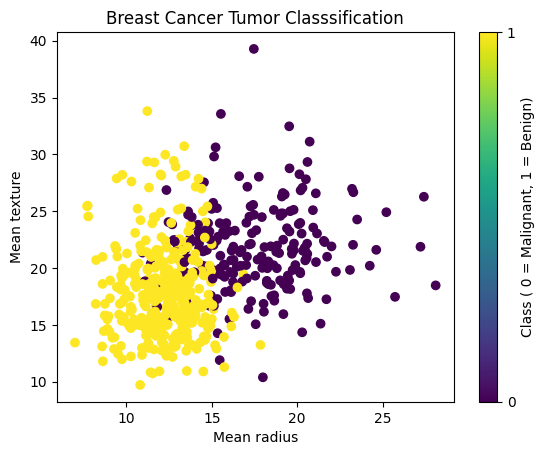

In [2]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [3]:
#Implementing KNN
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, x_test, k=3):
    distances = [euclidean_distance(x_test, x_train) for x_train in X_train]
    k_indices = np.argsort(distances)[:k]
    k_nearest_labels = [y_train[i] for i in k_indices]
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]

def knn_batch_predict(X_train, y_train, X_test, k=3):
    return np.array([knn_predict(X_train, y_train, x_test, k) for x_test in X_test])

In [8]:
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
#Running predictions
custom_preds = knn_batch_predict(X_train_scaled, y_train, X_test_scaled, k=5)
custom_acc = accuracy_score(y_test, custom_preds)
print(f"Custom KNN Accuracy: {custom_acc:.2f}")

Custom KNN Accuracy: 0.95


In [10]:
#Using scikit-learn's KNN
sklearn_knn = KNeighborsClassifier(n_neighbors=5)
sklearn_knn.fit(X_train_scaled, y_train)
sklearn_preds = sklearn_knn.predict(X_test_scaled)
sklearn_acc = accuracy_score(y_test, sklearn_preds)
print(f"Scikit-learn KNN Accuracy: {sklearn_acc:.2f}")


Scikit-learn KNN Accuracy: 0.95


In [11]:
#Comparing Results
print("\nComparison:")
print(f"Custom KNN correct: {(custom_preds == y_test).sum()} / {len(y_test)}")
print(f"Sklearn KNN correct: {(sklearn_preds == y_test).sum()} / {len(y_test)}")


Comparison:
Custom KNN correct: 108 / 114
Sklearn KNN correct: 108 / 114


The accuracy is the same achieved by scikit-learn! This result confirms that our custom KNN implementation is functioning correctly and yields results that are identical to the industry-standard implementation. That’s a great validation step!


Next we analyse what values have been classified in the wrong category:

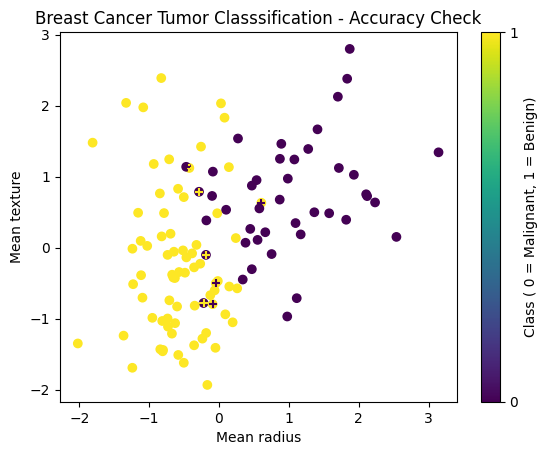

In [12]:
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c = custom_preds)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c = y_test, marker = '+')

plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification - Accuracy Check')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')
     

Despite the high accuracy, some classification errors remain. Interestingly, after testing different values for K, the number of misclassified points remained largely unchanged. This suggests that:

The errors are not due to a poor choice of K, but likely due to overlap or ambiguity in the feature space.

Specifically, because we are only using two features (radius and texture), some data points from different classes end up being very close in 2D space, leading to unavoidable misclassification.

In real-world applications, feeding the model additional features (like smoothness, compactness, concavity, etc.) could help disambiguate these edge cases and improve accuracy.

However, a problem for this dataset in particular is that most of the wrongly classified tumors have received a false-negative assignment. It is interesting in the medical field to have a prevalence of false-positives, a difference that could save lives! This suggests that given the importance of the analysis, KNN might not be the best method for analyzing critical data like this.